In [1]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\jmfc0\OneDrive\바탕 화면\data.csv"
df = pd.read_csv(file_path)

# 데이터 크기와 간단한 정보 확인
print("데이터 크기:", df.shape)
print(df.info())

# 모든 열을 순회하며 숫자 타입으로 변환 시도
for col in df.columns:
    if df[col].dtype == 'object':
        # 쉼표를 제거하고, 숫자로 변환할 수 없는 값(빈칸, 공백 포함)을 NaN으로 변경
        df[col] = pd.to_numeric(df[col].str.replace(',', '', regex=True), errors='coerce')


# 각 열의 결측치(NaN) 총 개수를 계산
missing_values = df.isnull().sum()

print("--- 최종 결측치 현황 ---")
print(missing_values[missing_values != 0])


데이터 크기: (25, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   합계출산율(명)                25 non-null     float64
 1   기대수명(출생시 기대여명)          25 non-null     float64
 2   고령인구(65세 이상)            25 non-null     object 
 3   생산연령인구 (15-64세)         25 non-null     object 
 4   국민연금 수급자 수 (명)          25 non-null     object 
 5   국민연금 수급자 수급금액 (단위:백만원)  25 non-null     object 
 6   국민연급 가입자 수 (명)          25 non-null     object 
 7   국내총생산(실질성장률) (%)        25 non-null     float64
 8   인플레이션율 (%)              25 non-null     float64
 9   실업률 (%)                 25 non-null     float64
 10  정규직 평균 연봉(단위: 만원, 만)    25 non-null     object 
 11  비정규직 평균 연봉(단위: 만원, 만)   25 non-null     int64  
 12  평균 연봉(단위: 만원, 만)        25 non-null     int64  
 13  정규직 근로자 수(단위: 만원, 만)    24 non-null     float64
 14  비정규직 근로자 수(단위: 만원, 만)   24 

In [2]:
# --- (전처리) 쉼표 제거 및 숫자/NaN으로 변환 ---
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col].str.replace(',', '', regex=True), errors='coerce')

# --- 보간 전, 결측치가 있는 행을 확인 ---
missing_rows_info = df[df.isnull().any(axis=1)]
print("--- 보간 전, 결측치가 있던 행의 상태 ---")
print(missing_rows_info[['정규직 근로자 수(단위: 만원, 만)', '비정규직 근로자 수(단위: 만원, 만)']])

# --- 후방 채우기(bfill)로 결측치 보간 실행 ---
# 첫 행의 결측치는 바로 다음 행의 값으로 채웁니다.
df.fillna(method='bfill', inplace=True)

# --- 보간 후, 해당 행의 값이 어떻게 채워졌는지 확인 ---
print("\n--- 보간 후, 해당 행의 채워진 값 ---")
print(df.loc[missing_rows_info.index][['정규직 근로자 수(단위: 만원, 만)', '비정규직 근로자 수(단위: 만원, 만)']])
df.drop('Unnamed: 31', axis=1, inplace=True)

# --- 최종 데이터 확인 ---
print("\n--- 보간 후 최종 데이터 정보 ---")
print(df.info())

--- 보간 전, 결측치가 있던 행의 상태 ---
    정규직 근로자 수(단위: 만원, 만)  비정규직 근로자 수(단위: 만원, 만)
0                    NaN                    NaN
1                  994.0                  364.0
2                 1016.0                  384.0
3                  954.0                  460.0
4                  918.0                  540.0
5                  948.0                  548.0
6                  989.0                  546.0
7                 1043.0                  537.0
8                 1077.0                  543.0
9                 1072.0                  575.0
10                1104.0                  584.0
11                1135.0                  593.0
12                1166.0                  602.0
13                1197.0                  611.0
14                1233.0                  607.0
15                1304.0                  627.0
16                1330.0                  637.0
17                1356.0                  643.0
18                1342.0                  661.0
19          

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26392\104080587.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [3]:
# 열 이름(컬럼명)을 깔끔하게 재정의
new_columns = [
    '합계출산율', '기대수명', '고령인구', '생산연령인구', '국민연금수급자수',
    '국민연금수급금액', '국민연금가입자수', '실질GDP성장률', '인플레이션율', '실업률',
    '정규직평균연봉', '비정규직평균연봉', '평균연봉', '정규직근로자수',
    '비정규직근로자수', '전체근로자수', '기금조성수익총액', '연금보험료',
    '운용수익', '국고보조금', '기금지출총액', '연금급여지급', '관리운영비',
    '기금증가분', '기금운용', '연도별기금운용수익률', '보험료율', '소득대체율','총 부양비','노년 부양비','연도별 소비자물가상승률(%)'
]
# 원본 데이터의 열 개수와 새 열 이름의 개수가 맞는지 확인 후 적용
if len(df.columns) == len(new_columns):
    df.columns = new_columns
    print("--- 모든 열 이름을 성공적으로 표준화했습니다. ---")
else:
    print(f"[오류] 원본 데이터의 열 개수({len(df.columns)})와 새 열 이름의 개수({len(new_columns)})가 다릅니다. 확인이 필요합니다.")


--- 모든 열 이름을 성공적으로 표준화했습니다. ---


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   합계출산율            25 non-null     float64
 1   기대수명             25 non-null     float64
 2   고령인구             25 non-null     int64  
 3   생산연령인구           25 non-null     int64  
 4   국민연금수급자수         25 non-null     int64  
 5   국민연금수급금액         25 non-null     int64  
 6   국민연금가입자수         25 non-null     int64  
 7   실질GDP성장률         25 non-null     float64
 8   인플레이션율           25 non-null     float64
 9   실업률              25 non-null     float64
 10  정규직평균연봉          25 non-null     int64  
 11  비정규직평균연봉         25 non-null     int64  
 12  평균연봉             25 non-null     int64  
 13  정규직근로자수          25 non-null     float64
 14  비정규직근로자수         25 non-null     float64
 15  전체근로자수           25 non-null     int64  
 16  기금조성수익총액         25 non-null     int64  
 17  연금보험료            2

In [5]:
from sklearn.preprocessing import StandardScaler
# 변수 모두 선택+담기
num_cols = df.select_dtypes(include=['number']).columns
X = df[num_cols]

# Z 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 표준화한 애 다시 DataFrame으로 만들기
df_scaled = pd.DataFrame(X_scaled, columns=num_cols, index=df.index)

df_scaled.head()

,합계출산율,기대수명,고령인구,생산연령인구,국민연금수급자수,국민연금수급금액,국민연금가입자수,실질GDP성장률,인플레이션율,실업률,...,연금급여지급,관리운영비,기금증가분,기금운용,연도별기금운용수익률,보험료율,소득대체율,총 부양비,노년 부양비,연도별 소비자물가상승률(%)
0,1.951269,-1.884630,-1.427709,-1.875534,-1.390302,-1.070594,-1.618034,2.560715,-0.204565,1.641380,...,-1.070597,-1.895055,-0.733347,-1.235415,-0.138179,0.0,1.392647,0.703283,-1.375060,-0.160831
1,1.068739,-1.681370,-1.334125,-1.685290,-1.379485,-1.073752,-1.587523,0.437794,1.190196,0.790924,...,-1.073748,-1.823135,-0.636439,-1.184596,0.522019,0.0,1.392647,0.703283,-1.291874,1.286646
2,0.392649,-1.559414,-1.235230,-1.523136,-1.324839,-1.044835,-1.488673,1.853074,0.182869,-0.697374,...,-1.044831,-1.742510,-0.597983,-1.128179,0.240278,0.0,1.392647,0.703283,-1.187892,0.241246
3,0.459741,-1.356153,-1.137984,-1.358293,-1.263398,-1.010301,-1.183391,-0.317023,0.725276,-0.059532,...,-1.010306,-1.678835,-0.554142,-1.065369,0.105716,0.0,1.392647,0.645825,-1.083910,0.804154
4,0.320395,-1.152893,-1.036739,-1.238503,-1.072636,-0.961362,-1.233267,0.673674,0.802762,0.153082,...,-0.961364,-0.773187,-0.470267,-0.990343,0.368533,0.0,1.392647,0.588367,-0.979927,0.884569


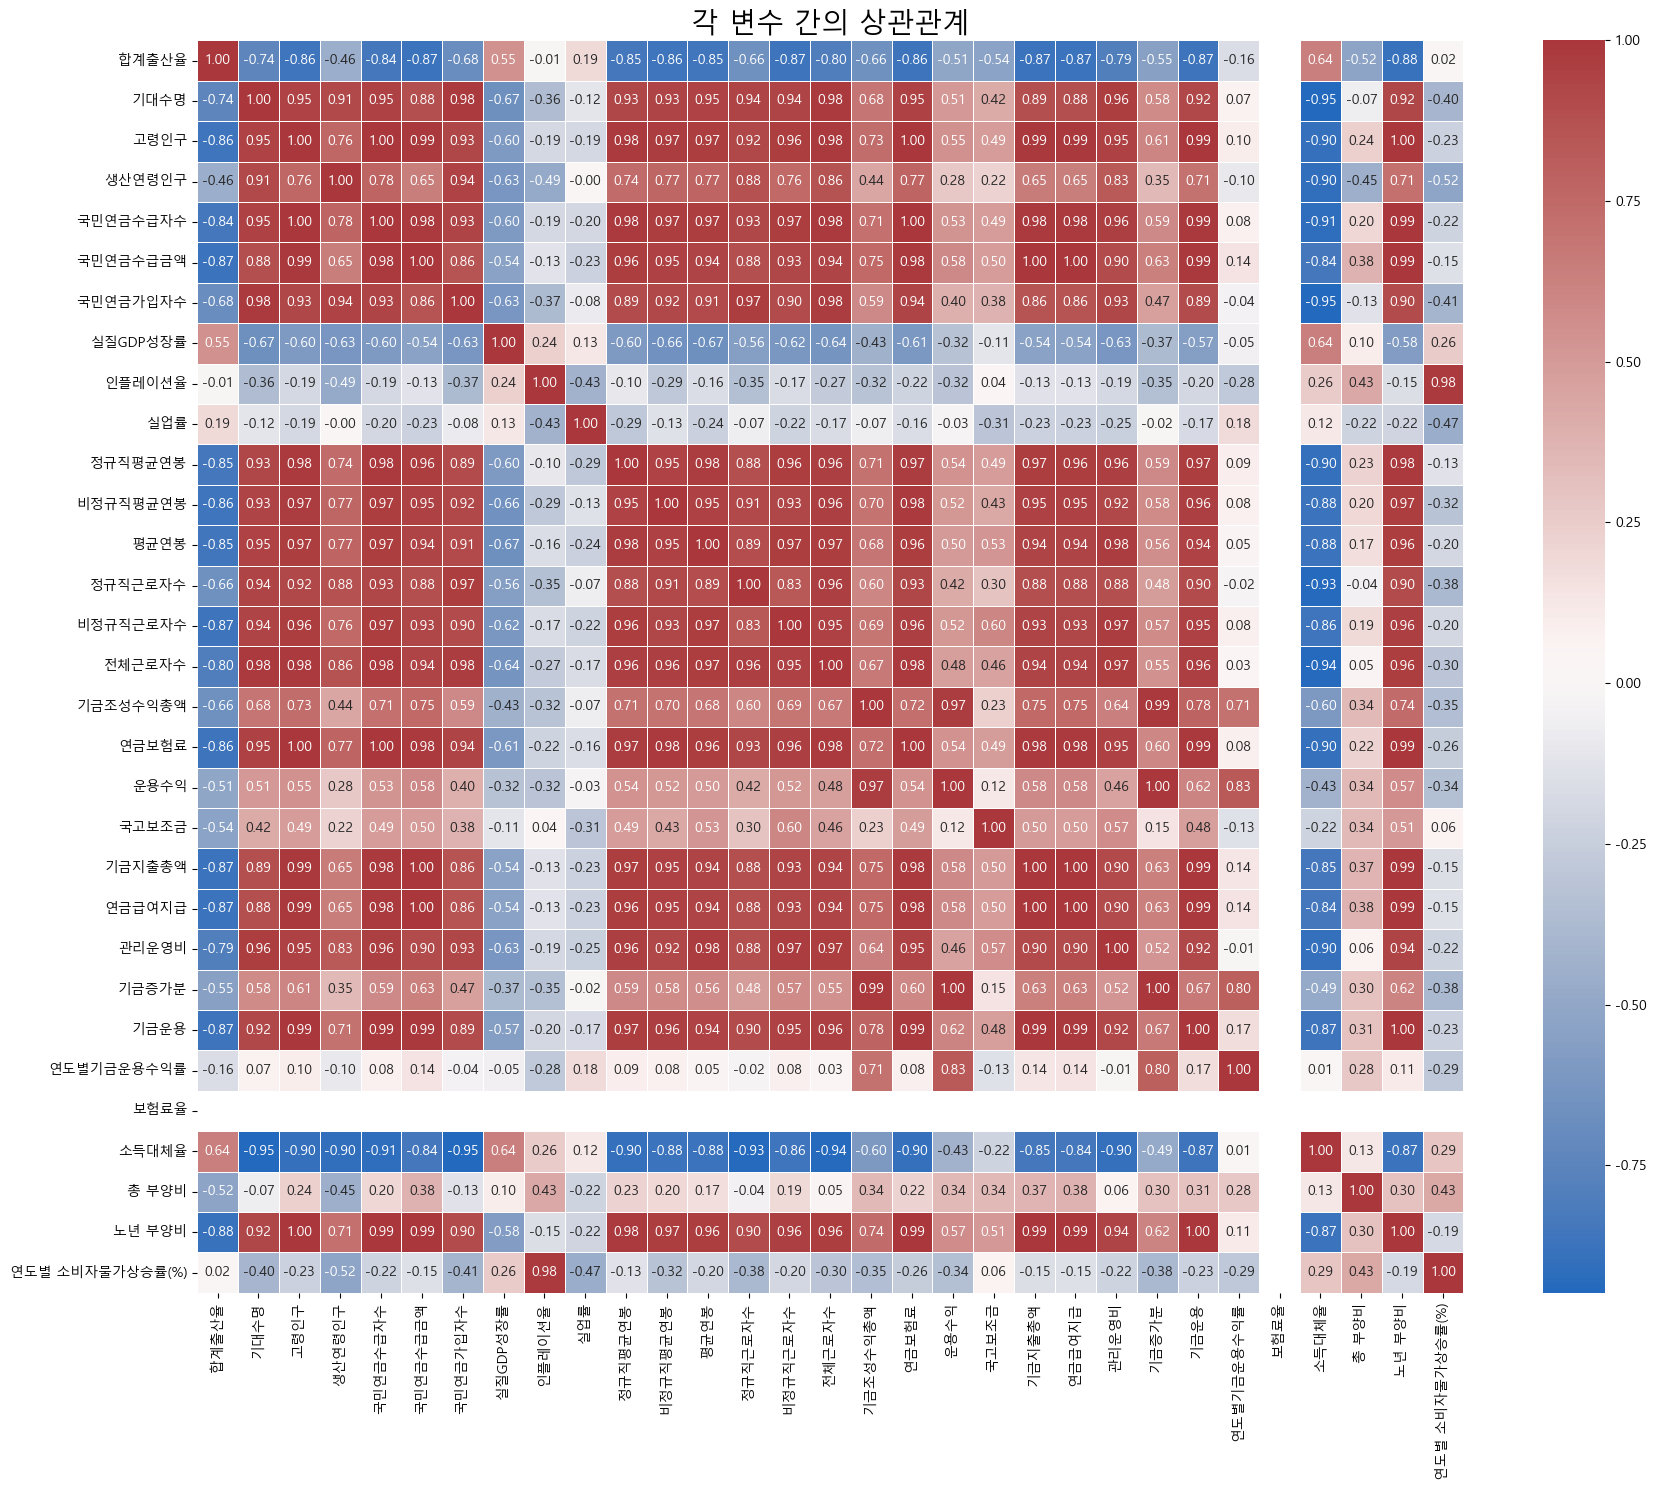

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 글꼴 
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호가 깨지지 않도록 설정
plt.rcParams['axes.unicode_minus'] = False

#--- 상관관계 행렬 계산 ---
# 데이터프레임의 모든 숫자 열 간의 상관관계를 계산합니다.
correlation_matrix = df.corr()

#--- 히트맵 생성 ---
# 그래프의 크기를 정합니다. (가로, 세로 인치 단위)
plt.figure(figsize=(18, 15))

# Seaborn 라이브러리를 사용해 히트맵을 그립니다.
sns.heatmap(
    correlation_matrix, 
    annot=True,          # 각 칸에 상관계수 숫자를 표시
    fmt=".2f",           # 숫자를 소수점 둘째 자리까지 표시
    cmap='vlag',         # 색상 스타일 지정 (vlag, coolwarm 등)
    linewidths=.5        # 칸 사이에 가는 선 추가
)

# 그래프의 제목을 추가합니다.
plt.title('각 변수 간의 상관관계', size=20)

# 레이아웃을 조정하여 잘리지 않도록 합니다.
plt.tight_layout()

# 그래프를 화면에 보여줍니다.
plt.show()

In [15]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# -------------------------------------------------------------------
# 1. 목표 변수(Y)와 새로운 철학에 따라 선택된 설명 변수(X)를 정의합니다.
# -------------------------------------------------------------------
df['수지비율'] = df['연금급여지급'] / df['연금보험료']

x_features_new_strategy = [
    '노년 부양비',
    '소득대체율',
    '실업률',
    '실질GDP성장률',
    '인플레이션율',
    '합계출산율',
    '연도별기금운용수익률'
]

y_new = df['수지비율']
X_new = df[x_features_new_strategy]
X_with_const_new = sm.add_constant(X_new)

print("--- [새로운 전략] 선택된 변수 목록 ---")
print(x_features_new_strategy)
print("\n")

# -------------------------------------------------------------------
# 2. 새로운 변수 조합에 대한 VIF를 계산합니다.
# -------------------------------------------------------------------
vif_df_new = pd.DataFrame()
vif_df_new["Feature"] = X_with_const_new.columns
vif_df_new["VIF"] = [variance_inflation_factor(X_with_const_new.values, i) for i in range(X_with_const_new.shape[1])]

print("--- [새로운 전략] VIF 계산 결과 ---")
print(vif_df_new)

--- [새로운 전략] 선택된 변수 목록 ---
['노년 부양비', '소득대체율', '실업률', '실질GDP성장률', '인플레이션율', '합계출산율', '연도별기금운용수익률']


--- [새로운 전략] VIF 계산 결과 ---
      Feature          VIF
0       const  2982.581724
1      노년 부양비    21.728966
2       소득대체율     9.157531
3         실업률     1.526111
4    실질GDP성장률     2.172808
5      인플레이션율     1.778406
6       합계출산율     9.156155
7  연도별기금운용수익률     1.227670


In [19]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# '수지비율' 변수가 이미 생성되었다고 가정합니다.

# -------------------------------------------------------------------
# 1. '노년 부양비'를 제거한 최종 변수 목록을 정의합니다.
# -------------------------------------------------------------------
x_features_ultimate_final = [
    # '노년 부양비', # VIF가 21.7로 최종 제거
    '소득대체율',
    '실업률',
    '실질GDP성장률',
    '인플레이션율',
    '합계출산율',
    '연도별기금운용수익률'
]

y_final = df['수지비율']
X_final = df[x_features_ultimate_final]
X_with_const_final = sm.add_constant(X_final)

print("--- [최종 선택] 변수 목록 ---")
print(x_features_ultimate_final)
print("\n")


# -------------------------------------------------------------------
# 2. 이 최종 조합에 대한 VIF를 마지막으로 확인합니다. [수정됨]
# -------------------------------------------------------------------
vif_df_final = pd.DataFrame()
vif_df_final["Feature"] = X_with_const_final.columns
vif_df_final["VIF"] = [variance_inflation_factor(X_with_const_final.values, i) for i in range(X_with_const_final.shape[1])]

print("--- 최종 변수 조합 VIF 확인 ---")
print(vif_df_final)
print("해석: 모든 변수의 VIF가 10 미만으로 안정화되었는지 확인합니다.")
print("\n")


# -------------------------------------------------------------------
# 3. 최종 GLSAR 모델을 구축하고 결과를 확인합니다.
# -------------------------------------------------------------------
# 자기상관 보정을 위해 GLSAR(rho=1) 모델 사용
final_glsar_model = sm.GLSAR(y_final, X_with_const_final, rho=1)
final_glsar_results = final_glsar_model.fit()

print("--- 최종 GLSAR 모델 분석 결과 ---")
print(final_glsar_results.summary())

--- [최종 선택] 변수 목록 ---
['소득대체율', '실업률', '실질GDP성장률', '인플레이션율', '합계출산율', '연도별기금운용수익률']


--- 최종 변수 조합 VIF 확인 ---
      Feature         VIF
0       const  149.388421
1       소득대체율    2.410280
2         실업률    1.349713
3    실질GDP성장률    1.867854
4      인플레이션율    1.656585
5       합계출산율    2.119542
6  연도별기금운용수익률    1.208321
해석: 모든 변수의 VIF가 10 미만으로 안정화되었는지 확인합니다.


--- 최종 GLSAR 모델 분석 결과 ---
                           GLSAR Regression Results                           
Dep. Variable:                   수지비율   R-squared:                       0.959
Model:                          GLSAR   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     65.49
Date:                Fri, 03 Oct 2025   Prob (F-statistic):           8.24e-11
Time:                        21:58:21   Log-Likelihood:                 47.790
No. Observations:                  24   AIC:                            -81.58
Df Residuals:                      17   BIC:                  